In [383]:
from __future__ import annotations

from pathlib import Path
from typing import Tuple, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from tqdm import tqdm
import os
from collections import Counter
import seaborn as sns
import matplotlib as mpl

import biotite.structure as struc
import biotite.structure.io.pdb as pdb
import biotite.structure.io.pdbx as pdbx

import biotite.sequence as seq
import biotite.sequence.align as align
from biotite.sequence.align import SubstitutionMatrix

df1 = pd.read_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/datasets/2p2idb/2p2idb_2024-04-08.csv', sep=";")
df2 = pd.read_csv('ppi_inhibitor_mapping.csv')

df_2p2idb = df2.merge(df1[['PDBProtProt', 'PDBProtLig', 'InChI']], on=['PDBProtProt', 'PDBProtLig'], how='left')
df_2p2idb = df_2p2idb[df_2p2idb['PDBProtProt'] != 'na']


def _load_structure_any(path: str, model: int = 1) -> struc.AtomArray:
    path = Path(path)
    suf = path.suffix.lower()
    if suf in {".pdb", ".ent"}:
        f = pdb.PDBFile.read(path)
        return f.get_structure(model=model)
    elif suf in {".cif", ".mmcif"}:
        f = pdbx.PDBxFile.read(path)
        return pdbx.get_structure(f, model=model)
    else:
        raise ValueError(f"Unsupported file type: {suf}")


def _select_chain_ca(arr: struc.AtomArray, chain_id: str, pdb_path: str) -> struc.AtomArray:
    mask = (arr.chain_id == chain_id)
    if not np.any(mask):
        raise ValueError(f"Chain '{chain_id}' not found in {pdb_path}. Available: {sorted(set(arr.chain_id.tolist()))}")
    arr = arr[mask]

    # Protein CA atoms
    arr = arr[struc.filter_amino_acids(arr) & (arr.atom_name == "CA")]
    if len(arr) == 0:
        raise ValueError(f"No protein CA atoms found on chain '{chain_id}' in {pdb_path}.")
    return arr


def _chain_sequence_and_resids(ca: struc.AtomArray) -> Tuple[seq.ProteinSequence, np.ndarray]:
    """
    Build a ProteinSequence from CA atoms and return residue ids in same order.
    """
    # Convert 3-letter to 1-letter; unknowns become 'X'
    one_letter = []
    for r3 in ca.res_name.astype(str):
        try:
            one_letter.append(seq.ProteinSequence.convert_letter_3to1(r3))
        except Exception:
            one_letter.append("X")
    s = seq.ProteinSequence("".join(one_letter))
    return s, ca.res_id.copy()


def _kabsch_refine(
    P: np.ndarray, Q: np.ndarray, *,
    cutoff: float = 2.0,
    cycles: int = 5
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, float, np.ndarray]:
    """
    Iteratively superimpose P onto Q with outlier rejection.
    Returns (R, t, fitted_P, rmsd, inlier_mask)
    where fitted_P = P @ R.T + t (row-vector convention).
    """
    if P.shape != Q.shape or P.shape[0] < 3:
        raise ValueError("Need matching point sets with at least 3 points.")

    inliers = np.ones(P.shape[0], dtype=bool)

    R = np.eye(3, dtype=float)
    t = np.zeros(3, dtype=float)
    fitted = P.copy()

    for _ in range(cycles):
        fitted_in, tf = struc.superimpose(Q[inliers], P[inliers])  # fit P -> Q on inliers
        # Apply tf to all P to recompute residuals for inlier selection
        fitted = tf.apply(P)

        d = np.linalg.norm(fitted - Q, axis=1)
        new_inliers = d <= cutoff

        # Stop if stable (or would drop too many)
        if np.array_equal(new_inliers, inliers):
            # keep tf from this iteration
            # Extract rotation and translation from the affine transformation
            R = tf.rotation[0]  # Remove batch dimension
            t = tf.target_translation[0] + tf.center_translation[0] @ R
            break

        # If we lost too many points, stop with previous inliers
        if new_inliers.sum() < 3:
            # revert to last stable fit on current inliers
            fitted_in, tf = struc.superimpose(Q[inliers], P[inliers])
            fitted = tf.apply(P)
            R = tf.rotation[0]
            t = tf.target_translation[0] + tf.center_translation[0] @ R
            break

        inliers = new_inliers
        R = tf.rotation[0]
        t = tf.target_translation[0] + tf.center_translation[0] @ R

    rmsd = float(struc.rmsd(fitted[inliers], Q[inliers]))
    return R, t, fitted, rmsd, inliers


def pymol_like_align_biotite(
    pdb1_path: str, chain1: str,
    pdb2_path: str, chain2: str,
    *,
    model1: int = 1,
    model2: int = 1,
    cutoff: float = 2.0,     # Å, similar spirit to PyMOL align outlier cutoff
    cycles: int = 5,
    gap_open: int = -10,
    gap_extend: int = -1,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, float, int]:
    """
    PyMOL cmd.align-like alignment:
    - Sequence align (BLOSUM62) to map residues
    - Superimpose matched CA coords
    - Iterative outlier rejection refinement

    Returns
    -------
    R : (3,3) rotation
    t : (3,) translation
    H : (4,4) homogeneous transform (row-vector usage: [x y z 1] @ H.T)
    rmsd : RMSD over inliers (Å)
    n_inliers : number of residue pairs used in final fit
    """
    a1 = _load_structure_any(pdb1_path, model=model1)
    a2 = _load_structure_any(pdb2_path, model=model2)

    ca1 = _select_chain_ca(a1, chain1, pdb1_path)
    ca2 = _select_chain_ca(a2, chain2, pdb2_path)

    s1, resids1 = _chain_sequence_and_resids(ca1)
    s2, resids2 = _chain_sequence_and_resids(ca2)

    matrix = SubstitutionMatrix.std_protein_matrix()  # BLOSUM62-like default in Biotite
    ali = align.align_optimal(
        s1, s2,
        matrix,
        gap_penalty=(gap_open, gap_extend),
        local=False
    )[0]

    # Get mapping indices from alignment
    # alignment.trace gives aligned positions; Biotite provides convenience:
    # Convert alignment to index pairs (i,j) where both are aligned (not gaps).
    i1_list: List[int] = []
    i2_list: List[int] = []

    # The trace is a 2D array where each row is [pos_in_seq1, pos_in_seq2]
    # A value of -1 indicates a gap in that sequence
    for trace_pos in ali.trace:
        pos1_idx = trace_pos[0]
        pos2_idx = trace_pos[1]
        # Only include positions where both sequences have residues (no gaps)
        if pos1_idx != -1 and pos2_idx != -1:
            i1_list.append(pos1_idx)
            i2_list.append(pos2_idx)

    if len(i1_list) < 3:
        raise ValueError(f"Sequence alignment produced only {len(i1_list)} matched residues (<3).")

    P = ca1.coord[np.array(i1_list)]  # mobile
    Q = ca2.coord[np.array(i2_list)]  # target

    R, t, fitted, rmsd, inliers = _kabsch_refine(P, Q, cutoff=cutoff, cycles=cycles)

    # Homogeneous matrix
    H = np.eye(4, dtype=float)
    H[:3, :3] = R
    H[:3, 3] = t

    return R, t, H, rmsd, int(inliers.sum())

def apply_rt(xyz: np.ndarray, R: np.ndarray, t: np.ndarray) -> np.ndarray:
    xyz = np.asarray(xyz, dtype=float)
    return xyz @ R.T + t


def get_block_coords(x, block_lengths):
    block_coords = []
    curr_length = 0
    for length in block_lengths:
        block_coords.append(x[curr_length:curr_length+length].mean(axis=0))
        curr_length += length
    return np.array(block_coords)


In [2]:
# Load inhibitors and PPIs
ppi_embeddings_df = pd.concat([pd.read_parquet('PPI_Partner_small_proteins_embeddings.parquet'), pd.read_parquet('PPI_Partner_very_small_proteins_embeddings.parquet')])
ppi_data2 = pd.concat([pd.read_parquet('PPI_Partner_small_proteins.parquet'), pd.read_parquet('PPI_Partner_very_small_proteins.parquet')])

ppi_embeddings_df = pd.merge(ppi_embeddings_df, ppi_data2, on='id', how='left')
ppi_to_family = df_2p2idb[['PDBProtProt', 'Chain_Target', 'Chain_Partner', 'Family']].drop_duplicates()
ppi_embeddings_df['pdb_id'] = ppi_embeddings_df['id'].str.split('_').str[0]
ppi_embeddings_df = pd.merge(ppi_embeddings_df, ppi_to_family, left_on='pdb_id', right_on='PDBProtProt', how='left')

inhibitor_embeddings_df = pd.read_parquet('PPI_inhibitors_v2_embeddings.parquet')
inhibitor_input_data = pd.read_parquet('PPI_inhibitors_v2_processed.parquet')
inhibitor_embeddings_df = pd.concat([inhibitor_input_data, inhibitor_embeddings_df.drop(columns=['id'])], axis=1)
inhibitor_embeddings_df['2P2IDB_ID'] = inhibitor_embeddings_df['id'].str.split('_').str[0]
inhibitor_embeddings_df = inhibitor_embeddings_df.merge(df_2p2idb[['2P2IDB_ID', 'PDBProtLig', 'Chain_Target', 'ChainID_Ligand', 'Family']], on='2P2IDB_ID', how='left')

In [166]:
def get_block_emb_dist(inhibitor_index, inhibitor_pdb_id, inhibitor_chain_target, ppi_pdb_id, ppi_chain_target, ppi_chain_partner):
    CIF_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/datasets/2p2idb/2p2idb_2024-04-08_cifs/"
    # align the target chains
    R, t, H, rmsd, _ = pymol_like_align_biotite(
        CIF_DIR + f"{inhibitor_pdb_id}.cif", inhibitor_chain_target, # inhibitor
        CIF_DIR + f"{ppi_pdb_id}.cif", ppi_chain_target, # PPI
    )
    # print(f"RMSD {inhibitor_pdb_id} -> {ppi_pdb_id}: {rmsd}")

    # Get PPI blocks 
    ppi_entry = ppi_embeddings_df[ppi_embeddings_df['id'] == f'{ppi_pdb_id}_{ppi_chain_partner}'].iloc[0]
    ppi_coords = np.stack(ppi_entry['X'])
    ppi_block_lengths = ppi_entry['block_lengths']
    ppi_block_coords = get_block_coords(ppi_coords, ppi_block_lengths)
    ppi_block_emb = np.stack(ppi_entry['block_embedding'])

    # Get inhibitor blocks
    inhibitor_entry = inhibitor_embeddings_df.iloc[inhibitor_index]
    num_pocket_atoms = inhibitor_entry['block_lengths'][inhibitor_entry['segment_ids'] == 0].sum()
    inhibitor_coords = np.stack(inhibitor_entry['X'])[num_pocket_atoms:]
    inhibitor_block_lengths = inhibitor_entry['block_lengths'][inhibitor_entry['segment_ids'] == 1]
    
    inhibitor_block_lengths_no_atom = inhibitor_block_lengths > 1
    if inhibitor_block_lengths_no_atom.sum() == 0:
        print(f"No inhibitor blocks of size > 1 for {inhibitor_pdb_id}_{inhibitor_chain_target}_{lig_code}_index_{inhibitor_index}")
        return None, None

    inhibitor_coords = apply_rt(inhibitor_coords, R, t)
    inhibitor_block_coords = get_block_coords(inhibitor_coords, inhibitor_block_lengths)
    inhibitor_block_emb = np.stack(inhibitor_entry['block_embedding'][inhibitor_entry['segment_ids'] == 1])

    block_emb_dist = scipy.spatial.distance.cdist(inhibitor_block_emb, ppi_block_emb, metric='cosine') # (n_inhibitor_blocks, n_ppi_blocks)
    block_coords_dist = scipy.spatial.distance.cdist(inhibitor_block_coords, ppi_block_coords) # (n_inhibitor_blocks, n_ppi_blocks)

    # Remove blocks of size 1 from the inhibitor (these are atom blocks or global blocks)
    block_emb_dist = block_emb_dist[inhibitor_block_lengths > 1, :]
    block_coords_dist = block_coords_dist[inhibitor_block_lengths > 1, :]
    block_emb_dist = block_emb_dist[:, ppi_block_lengths > 1]
    block_coords_dist = block_coords_dist[:, ppi_block_lengths > 1]
    return block_emb_dist, block_coords_dist

In [164]:
families = list(set(inhibitor_embeddings_df['Family'].unique()).intersection(set(ppi_embeddings_df['Family'].unique())))
families

['BAZ2B/H4',
 'HDM2/P53',
 'BAZ2A/H4',
 'BRPF1/H4',
 'BRD9/H4',
 'EP300/H4',
 'TAF1-2/H4',
 'XIAP-BIR2/CASPASE-3',
 'WDR5/MLL1',
 'XDM2/P53',
 'ATAD2/H4',
 'WDR5-2/MYC',
 'CIAP1-BIR3/CASPASE-9',
 'KEAP1/NRF2',
 'FALZ/H4',
 'BCL2/BAX',
 'BRD3-2/H3',
 'BRD2-1/H4',
 'CREBBP/H4',
 'DCN1/UBC12',
 'MKEAP1/MNRF2',
 'BCLXL/BAK',
 'MENIN/MLL',
 'TRIM24/H4',
 'MDM4/P53',
 'BRD4-1/H4',
 'ZIPA/FTSZ']

In [312]:
def run_one_inhibitor(inhibitor_entry):
    ppi_entry = ppi_embeddings_df[ppi_embeddings_df['Family'] == inhibitor_entry['Family']].iloc[0]
    ppi_pdb_id = ppi_entry['pdb_id']
    ppi_chain_target = ppi_entry['Chain_Target']
    ppi_chain_partner = ppi_entry['Chain_Partner']
    
    inhibitor_pdb_id = inhibitor_entry['PDBProtLig']
    inhibitor_chain_target = inhibitor_entry['Chain_Target']
    lig_code = inhibitor_entry['id'].split('_')[-1]

    block_emb_dist, block_coords_dist = get_block_emb_dist(inhibitor_entry.name, inhibitor_pdb_id, inhibitor_chain_target, ppi_pdb_id, ppi_chain_target, ppi_chain_partner)
    if block_emb_dist is not None:
        pearsonr, p_value = scipy.stats.pearsonr(block_emb_dist.flatten(), block_coords_dist.flatten())
    else:
        pearsonr, p_value = None, None
    return pd.Series({
        'ppi_pdb_id': ppi_pdb_id,
        'ppi_chain_target': ppi_chain_target,
        'ppi_chain_partner': ppi_chain_partner,
        'inhibitor_pdb_id': inhibitor_pdb_id,
        'inhibitor_chain_target': inhibitor_chain_target,
        'family': inhibitor_entry['Family'],
        'lig_code': lig_code,
        'inhibitor_index': inhibitor_entry.name,
        'min_dist': block_coords_dist.min() if block_coords_dist is not None else None,
        'block_emb_dist': block_emb_dist.flatten() if block_emb_dist is not None else None,
        'block_coords_dist': block_coords_dist.flatten() if block_coords_dist is not None else None,
        'pearsonr': pearsonr,
        'p_value': p_value,
    })

if not os.path.exists('ppi_inhibitor_block_results.parquet'):
    block_results = inhibitor_embeddings_df[inhibitor_embeddings_df['Family'].isin(families)].apply(run_one_inhibitor, axis=1)
    block_results.to_parquet('ppi_inhibitor_block_results.parquet')
else:
    block_results = pd.read_parquet('ppi_inhibitor_block_results.parquet')

block_results = block_results.dropna(subset=['min_dist'])
block_results = block_results[block_results['min_dist'] < 2].reset_index(drop=True)

In [410]:
def precision_at_k(E: np.ndarray, G: np.ndarray, k: int = 5, geom_thresh: float = 4.0) -> float:
    k = min(k, max(10, int(E.size * 0.1)))
    E = np.asarray(E).reshape(-1)
    G = np.asarray(G).reshape(-1)
    assert E.shape == G.shape
    if E.size <= k:
        k = 1
    assert 1 <= k <= E.size, f"k={k} must be between 1 and {E.size}"
    topk = np.argsort(E)[:k]
    return float(np.mean(G[topk] <= geom_thresh))


def enrichment_at_k(E: np.ndarray, G: np.ndarray, k: int = 5, geom_thresh: float = 4.0) -> float:
    E = np.asarray(E).reshape(-1)
    G = np.asarray(G).reshape(-1)
    assert E.shape == G.shape

    base_rate = float(np.mean(G <= geom_thresh))
    if base_rate == 0.0:
        return float("nan")  # no positives -> enrichment undefined

    prec = precision_at_k(E, G, k=k, geom_thresh=geom_thresh)
    return float(prec / base_rate)

In [482]:
KAAAY = 10
block_results['precision_at_k'] = block_results.apply(lambda row: precision_at_k(row['block_emb_dist'], row['block_coords_dist'], k=KAAAY, geom_thresh=4), axis=1)
block_results['enrichment_at_k'] = block_results.apply(lambda row: enrichment_at_k(row['block_emb_dist'], row['block_coords_dist'], k=KAAAY, geom_thresh=4), axis=1)

print("Number of families with enrichment at k: ", (block_results['enrichment_at_k'] > 1).sum(), "out of", len(block_results))

block_results_best = block_results.groupby('family').agg({
    'precision_at_k': 'max',
    'enrichment_at_k': 'max',
}).reset_index()

print("Number of families with enrichment at k: ", (block_results_best['enrichment_at_k'] > 1).sum(), "out of", len(block_results_best))
block_results_best

Number of families with enrichment at k:  167 out of 273
Number of families with enrichment at k:  12 out of 16


,family,precision_at_k,enrichment_at_k
0,ATAD2/H4,1.0,5.000000
1,BCL2/BAX,0.0,0.000000
2,BCLXL/BAK,0.1,3.300000
3,BRD2-1/H4,0.3,3.000000
4,BRD4-1/H4,0.3,5.600000
5,BRD9/H4,0.2,4.000000
6,CIAP1-BIR3/CASPASE-9,0.5,1.272727
7,DCN1/UBC12,0.1,1.600000
8,HDM2/P53,0.2,2.600000
9,KEAP1/NRF2,0.0,0.000000


/tmp/ipykernel_1349801/2874841560.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


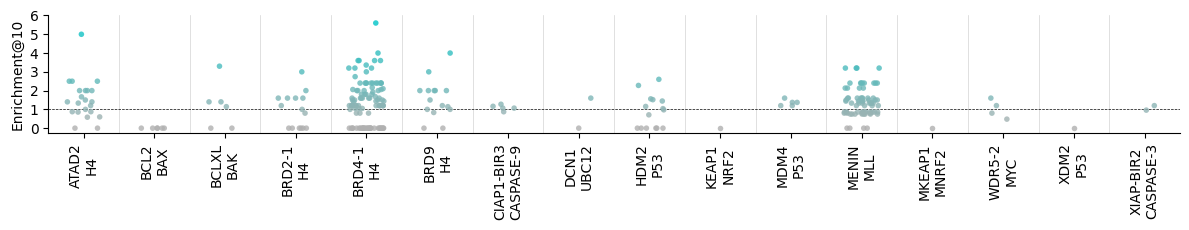

In [577]:
plt.figure(figsize=(12, 12/5))

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "gray_to_aqua",
    ["#B0B0B0", "#00C4C7"]  # gray → your color
)

order = sorted(block_results['family'].unique())
ax = sns.stripplot(x='family', y='enrichment_at_k', data=block_results,
              size=4, alpha=0.8, jitter=0.25, palette=cmap, hue='enrichment_at_k', order=order)
ax.get_legend().remove()
new_labels = [label.get_text().replace('/', '\n') for label in ax.get_xticklabels()]
ax.set_xticklabels(new_labels)
plt.xticks(rotation=90)
plt.axhline(1.0, linestyle='--', color='black', linewidth=0.5)

plt.ylabel(f"Enrichment@{KAAAY}")
ax.set_yticks(range(7))
plt.xlabel("")

n_families = block_results['family'].nunique()

for i in range(n_families - 1):
    plt.axvline(i + 0.5, color='lightgray', linewidth=0.5, zorder=0)

sns.despine()
plt.tight_layout()
plt.savefig(f"figures/plots/small_proteins_enrichment_at_k_{KAAAY}.svg")
plt.show()

/tmp/ipykernel_1349801/3961122174.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


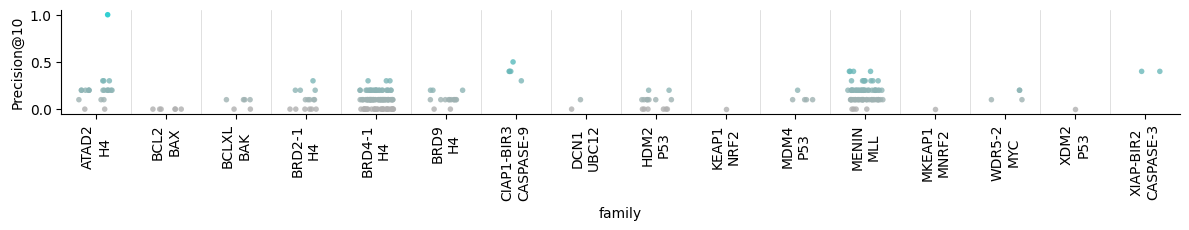

In [578]:
plt.figure(figsize=(12, 12/5))

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "gray_to_aqua",
    ["#B0B0B0", "#00C4C7"]  # gray → your color
)

order = sorted(block_results['family'].unique())
ax = sns.stripplot(x='family', y='precision_at_k', data=block_results,
              size=4, alpha=0.8, jitter=0.25, palette=cmap, hue='precision_at_k', order=order)
ax.get_legend().remove()
new_labels = [label.get_text().replace('/', '\n') for label in ax.get_xticklabels()]
ax.set_xticklabels(new_labels)
plt.xticks(rotation=90)

plt.ylabel(f"Precision@{KAAAY}")

n_families = block_results['family'].nunique()

for i in range(n_families - 1):
    plt.axvline(i + 0.5, color='lightgray', linewidth=0.5, zorder=0)

plt.tight_layout()
sns.despine()
plt.savefig(f"figures/plots/small_proteins_precision_at_k_{KAAAY}.svg")
plt.show()

In [573]:
# Swarm plot, x = dist inhibitor-ppi, y = dist patch to target chain
k = 10

entry = block_results.sort_values(by='precision_at_k', ascending=False).iloc[8]
closest_ppi_idx = np.argsort(entry['block_emb_dist'])[:k]
furthest_ppi_idx = np.argsort(entry['block_emb_dist'])[-k:]
random_ppi_idx = np.arange(len(entry['block_emb_dist']))
ppi_idx = np.concatenate([closest_ppi_idx, furthest_ppi_idx, random_ppi_idx])
swarm_plot_data = {
    'Distance between Blocks': entry['block_coords_dist'][ppi_idx],
    'type': np.array([f'Top {k}'] * len(closest_ppi_idx) + [f'Bottom {k}'] * len(furthest_ppi_idx) + [f'Reference'] * len(random_ppi_idx))
}
swarm_plot_data = pd.DataFrame(swarm_plot_data) 

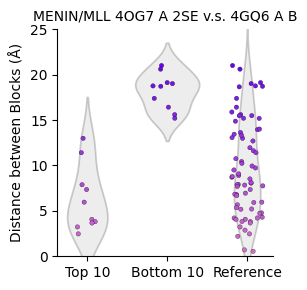

In [582]:
plt.figure(figsize=(3, 3))

# Draw violin first
ax = sns.violinplot(
    x='type',
    y='Distance between Blocks',
    data=swarm_plot_data,
    inner=None,
    color='lightgray',
    alpha=0.4
)

# Create colormap
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "gray_to_purple",
    ["#D86ECC", "#6805F2"]
)

# Get exact x positions used by seaborn
xticks = ax.get_xticks()
categories = [t.get_text() for t in ax.get_xticklabels()]
pos_dict = dict(zip(categories, xticks))

# Map each row to correct x position
x_vals = swarm_plot_data['type'].map(pos_dict).values

# Add jitter
jitter = np.random.uniform(-0.2, 0.2, size=len(x_vals))

sc = ax.scatter(
    x_vals + jitter,
    swarm_plot_data['Distance between Blocks'],
    c=swarm_plot_data['Distance between Blocks'],
    cmap=cmap,
    s=10,
    edgecolor='black',
    linewidth=0.2
)

sns.despine()

plt.ylabel('Distance between Blocks (Å)')
plt.ylim(0, 25)
plt.xlabel('')
plt.title(f"{entry['family']} {entry['inhibitor_pdb_id']} {entry['inhibitor_chain_target']} {entry['lig_code']} v.s. {entry['ppi_pdb_id']} {entry['ppi_chain_target']} {entry['ppi_chain_partner']}", fontsize=10)
plt.tight_layout()

plt.savefig(f"figures/plots/{entry['family'].replace('/','.')}_block_dist_vs_emb_dist_swarm.svg")
plt.show()

# Other plots

In [ ]:
block_results_agg_family = block_results.groupby('family').agg({
    'block_emb_dist': lambda x: np.concatenate(list(x)),
    'block_coords_dist': lambda x: np.concatenate(list(x)),
    'lig_code': lambda x: Counter(x),
    'inhibitor_index': 'count',
    'pearsonr': lambda x: list(x),
    'p_value': lambda x: list(x),
}).reset_index().rename(columns={
    'inhibitor_index': 'total_inhibitor_count',
})

block_results_agg_family['precision_at_k'] = block_results_agg_family.apply(lambda row: precision_at_k(row['block_emb_dist'], row['block_coords_dist'], k=10, geom_thresh=4), axis=1)
block_results_agg_family['enrichment_at_k'] = block_results_agg_family.apply(lambda row: enrichment_at_k(row['block_emb_dist'], row['block_coords_dist'], k=10, geom_thresh=4), axis=1)

block_results_agg_family['best_pearsonr'] = block_results_agg_family['pearsonr'].apply(lambda x: max(x))
block_results_agg_family['best_p_value'] = block_results_agg_family.apply(lambda row: row['p_value'][row['pearsonr'].index(row['best_pearsonr'])], axis=1)

block_results_agg_family[['pearsonr_agg', 'p_value_agg']] = (
    block_results_agg_family
    .apply(
        lambda row: pd.Series(
            scipy.stats.pearsonr(row['block_emb_dist'], row['block_coords_dist']),
            index=['pearsonr_agg', 'p_value_agg']
        ),
        axis=1
    )
)

print("Number of families with enrichment at k: ", (block_results_agg_family['enrichment_at_k'] > 1).sum(), "out of", len(block_results_agg_family))

Number of families with enrichment at k:  7 out of 16


/tmp/ipykernel_1349801/2613472448.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  block_results_agg_family = block_results.dropna(subset=['min_dist'])[block_results['min_dist'] < 2].groupby('family').agg({


In [310]:
block_results_agg_family

,family,block_emb_dist,block_coords_dist,lig_code,total_inhibitor_count,pearsonr,p_value,precision_at_k,enrichment_at_k,best_pearsonr,best_p_value,pearsonr_agg,p_value_agg
0,ATAD2/H4,"[0.5648886548624228, 0.5028676866446107, 0.523...","[9.16841598340642, 8.783497788582583, 5.199400...","{'J5I': 1, 'JTF': 1, '6XC': 1, 'NP8': 1, '78J'...",22,"[0.830389182929832, -0.012524610730288616, -0....","[0.08168538943171327, 0.9646648086664584, 0.90...",0.3,2.045455,0.830389,8.168539e-02,0.188919,3.163235e-06
1,BCL2/BAX,"[0.5011538058188708, 0.35227705302293055, 0.23...","[23.076135621268413, 23.896914567801623, 19.77...","{'43B': 2, 'LIU': 1, 'LI0': 1, '1XJ': 1, 'LBM'...",6,"[0.2626966873153665, 0.2607342404470775, 0.163...","[0.0009227543170266747, 0.0010110587265703744,...",0.0,0.000000,0.278879,1.376940e-04,0.130950,4.374515e-06
2,BCLXL/BAK,"[0.6572255432729871, 0.6210363828804322, 0.581...","[15.553132946141925, 14.454622071363996, 12.26...","{'4FC': 2, 'N3B': 1, 'X0J': 1, 'LBM': 1, 'XOU'...",6,"[0.16970916725882493, 0.16970916725882493, -0....","[0.28261332953351337, 0.28261332953351337, 0.1...",0.1,1.837500,0.539717,7.298516e-19,0.107331,3.576174e-03
3,BRD2-1/H4,"[0.6009024662378557, 0.7981569064658525, 0.663...","[17.1160390442849, 14.304399492616115, 12.2476...","{'WSH': 1, 'EAM': 1, 'TVP': 1, 'P9I': 1, 'TYL'...",15,"[0.23541067799681442, -0.122123929775556, 0.26...","[0.14365989474092733, 0.45283077311452724, 0.3...",0.0,0.000000,0.415997,1.090142e-01,-0.042297,3.357293e-01
4,BRD4-1/H4,"[0.4788173204182722, 0.5052268015253796, 0.321...","[13.03437340198829, 11.766351955579498, 12.985...","{'JQ1': 2, 'ODR': 1, '08H': 1, '08K': 1, '1GH'...",101,"[0.03194836466718813, -0.016349273806046845, -...","[0.7899200952990402, 0.9246008792706499, 0.247...",0.2,3.030698,0.264402,1.191616e-01,-0.055587,7.133709e-06
5,BRD9/H4,"[0.7206906139196194, 0.5143233932159801, 0.686...","[10.379021470395593, 8.964622279108728, 5.6104...","{'N1D': 1, 'TVU': 1, 'XZB': 1, 'H1B': 1, '5SW'...",15,"[0.06697517524312382, 0.1274365818202632, -0.0...","[0.6439901406188981, 0.33188797877155746, 0.95...",0.2,2.588235,0.205271,2.765159e-01,-0.002384,9.512583e-01
6,CIAP1-BIR3/CASPASE-9,"[0.6017018038807621, 0.5916486183084997, 0.536...","[9.57637908043159, 6.8302981150250766, 3.24872...","{'1BG': 1, '1Y0': 1, '1YH': 1, '2DY': 1, '7H9'...",5,"[0.17855498161933858, 0.021965897892129257, -0...","[0.32819278752650816, 0.9116588290567635, 0.96...",0.2,0.547368,0.178555,3.281928e-01,-0.021155,7.932182e-01
7,DCN1/UBC12,"[0.6369637826495143, 0.8003012455153107, 0.841...","[7.832420383630047, 6.385135648652909, 11.8136...","{'8Z7': 1, '8ZD': 1}",2,"[0.38567765527747544, 0.3093124454499467]","[0.006784610530259954, 0.0021657908664951602]",0.0,0.000000,0.385678,6.784611e-03,0.335563,3.930521e-05
8,HDM2/P53,"[0.4898550541920472, 0.6108804105178576, 0.558...","[6.077067625447714, 2.641797693782311, 3.33786...","{'K23': 1, '0R2': 1, '28W': 2, '2TW': 1, '2U7'...",15,"[0.08956760429118807, 0.16988763233085627, 0.1...","[0.4354865442367273, 0.10740921651619761, 0.08...",0.1,1.324762,0.386913,5.434628e-06,0.126546,2.196423e-06
9,KEAP1/NRF2,"[0.8657340411226446, 0.642561188093471, 0.7685...","[23.34610525217433, 24.305182279144397, 22.895...",{'12O': 1},1,[0.6548351167125095],[4.581181233859665e-13],0.0,0.000000,0.654835,4.581181e-13,0.654835,4.581181e-13


In [263]:
print("Number of families with significant correlation: ", len(block_results_agg_family[(block_results_agg_family['best_p_value'] < 0.05) & (block_results_agg_family['best_pearsonr'] > 0)]))
print("Number of aggregated families with significant correlation: ", len(block_results_agg_family[(block_results_agg_family['p_value_agg'] < 0.05) & (block_results_agg_family['pearsonr_agg'] > 0)]))

Number of families with significant correlation:  9
Number of aggregated families with significant correlation:  8


In [336]:
chosen_family = "MDM4/P53" #block_results_agg_family['family'].iloc[20]
print("Chosen family: ", chosen_family)
best_pearsonr = block_results_agg_family[block_results_agg_family['family'] == chosen_family]['best_pearsonr'].iloc[0]
entry = block_results[(block_results['family'] == chosen_family) & (block_results['pearsonr'] == best_pearsonr)]
if len(entry) > 1:
    print(f"WARNING: Multiple entries for {chosen_family} with Pearson R {best_pearsonr}")

agg_entry = block_results_agg_family[block_results_agg_family['family'] == chosen_family].iloc[0]
entry = entry.iloc[0]

Chosen family:  MDM4/P53


-0.030364189677094377 0.5069049925482983


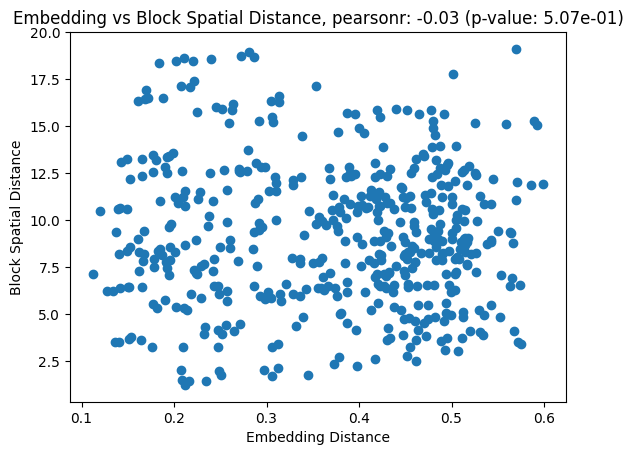

In [337]:
pearsonr_corr, p_value = scipy.stats.pearsonr(agg_entry['block_emb_dist'], agg_entry['block_coords_dist'])
print(pearsonr_corr, p_value)
plt.scatter(agg_entry['block_emb_dist'], agg_entry['block_coords_dist'])
plt.xlabel('Embedding Distance')
plt.ylabel('Block Spatial Distance')
plt.title(f'Embedding vs Block Spatial Distance, pearsonr: {pearsonr_corr:.2f} (p-value: {p_value:.2e})')
plt.savefig(f"figures/small_proteins/{chosen_family.replace('/','.')}_block_dist_vs_emb_dist.png", dpi=300)
plt.show()

PearsonRResult(statistic=0.03064908464319209, pvalue=0.7668983892970587)


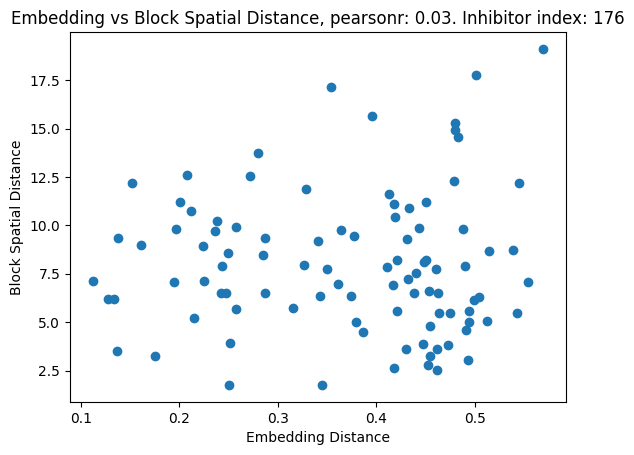

In [338]:
pearsonr_corr = scipy.stats.pearsonr(entry['block_emb_dist'], entry['block_coords_dist'])
print(pearsonr_corr)
plt.scatter(entry['block_emb_dist'], entry['block_coords_dist'])
plt.xlabel('Embedding Distance')
plt.ylabel('Block Spatial Distance')
plt.title(f'Embedding vs Block Spatial Distance, pearsonr: {pearsonr_corr[0]:.2f}. Inhibitor index: {entry["inhibitor_index"]}')
plt.savefig(f"figures/small_proteins/{chosen_family.replace('/','.')}_block_dist_vs_emb_dist_best.png", dpi=300)
plt.show()

<Axes: xlabel='type', ylabel='emb_dist'>

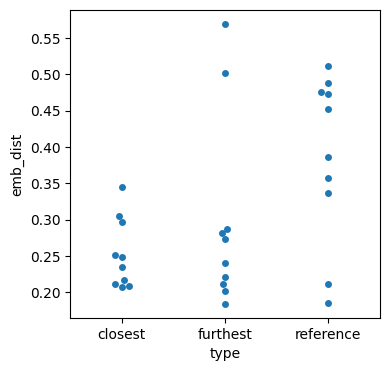

In [433]:
# Swarm plot, x = dist inhibitor-ppi, y = dist patch to target chain
k = 10

plt.figure(figsize=(4, 4))

closest_ppi_idx = np.argsort(agg_entry['block_coords_dist'])[:k]
furthest_ppi_idx = np.argsort(agg_entry['block_coords_dist'])[-k:]
random_ppi_idx = np.random.randint(0, len(agg_entry['block_coords_dist']), size=(k))
ppi_idx = np.concatenate([closest_ppi_idx, furthest_ppi_idx, random_ppi_idx])

swarm_plot_data = {
    'emb_dist': agg_entry['block_emb_dist'][ppi_idx],
    'type': np.array(['closest'] * len(closest_ppi_idx) + ['furthest'] * len(furthest_ppi_idx) + ['reference'] * len(random_ppi_idx))
}
swarm_plot_data = pd.DataFrame(swarm_plot_data)

sns.swarmplot(x='type', y='emb_dist', data=swarm_plot_data)

In [341]:
import numpy as np

def cumulative_hit_curve(E: np.ndarray,
                         G: np.ndarray,
                         geom_thresh: float = 8.0,
                         normalize_x: bool = True):
    """
    Compute cumulative hit curve for embedding vs geometric proximity.
    
    Parameters
    ----------
    E : np.ndarray
        Embedding distances (smaller = more similar)
    G : np.ndarray
        Geometric distances (smaller = closer in 3D)
    geom_thresh : float
        Threshold defining geometric "positive"
    normalize_x : bool
        If True, x-axis returned as percentile (0-1),
        otherwise as rank index (1..N)
    
    Returns
    -------
    x : np.ndarray
        Rank positions (percentile or absolute rank)
    cumulative_precision : np.ndarray
        Cumulative fraction of geometric positives up to each rank
    baseline : float
        Expected precision under random selection
    """
    E = np.asarray(E).reshape(-1)
    G = np.asarray(G).reshape(-1)
    assert E.shape == G.shape

    N = len(E)

    # Define geometric positives
    positives = (G <= geom_thresh).astype(int)

    # Sort by embedding distance (ascending)
    order = np.argsort(E)
    sorted_pos = positives[order]

    # Cumulative hits
    cumulative_hits = np.cumsum(sorted_pos)

    # Precision up to each rank
    ranks = np.arange(1, N + 1)
    cumulative_precision = cumulative_hits / ranks

    # X-axis scaling
    if normalize_x:
        x = ranks / N
    else:
        x = ranks

    # Random baseline (flat line)
    baseline = positives.mean()

    return x, cumulative_precision, baseline


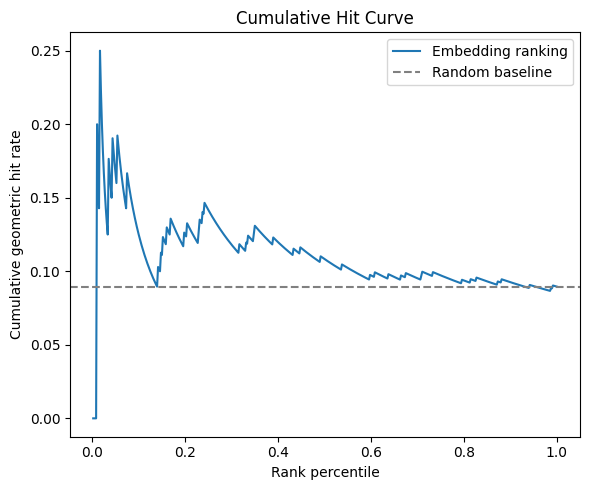

In [342]:
x, cum_prec, baseline = cumulative_hit_curve(agg_entry['block_emb_dist'], agg_entry['block_coords_dist'], geom_thresh=4.0)

plt.figure(figsize=(6,5))
plt.plot(x, cum_prec, label="Embedding ranking")
plt.axhline(baseline, linestyle="--", color="gray", label="Random baseline")
plt.xlabel("Rank percentile")
plt.ylabel("Cumulative geometric hit rate")
plt.legend()
plt.title("Cumulative Hit Curve")
plt.tight_layout()
plt.show()

In [343]:
import numpy as np

def precision_at_k_curve(E: np.ndarray,
                         G: np.ndarray,
                         geom_thresh: float = 8.0,
                         k_values=None):
    """
    Compute Precision@k curve for embedding vs geometric proximity.
    
    Parameters
    ----------
    E : np.ndarray
        Embedding distances (smaller = more similar)
    G : np.ndarray
        Geometric distances (smaller = closer)
    geom_thresh : float
        Threshold defining geometric positive
    k_values : list or array
        Values of k to evaluate (default: 1..N)
    
    Returns
    -------
    k_values : np.ndarray
        k values used
    precision : np.ndarray
        Precision@k for each k
    baseline : float
        Expected precision under random
    """
    E = np.asarray(E).reshape(-1)
    G = np.asarray(G).reshape(-1)
    assert E.shape == G.shape

    N = len(E)

    positives = (G <= geom_thresh).astype(int)

    # Sort by embedding similarity
    order = np.argsort(E)
    sorted_pos = positives[order]

    if k_values is None:
        k_values = np.arange(1, N + 1)

    precision = []
    for k in k_values:
        precision.append(sorted_pos[:k].mean())

    precision = np.array(precision)

    baseline = positives.mean()

    return np.array(k_values), precision, baseline


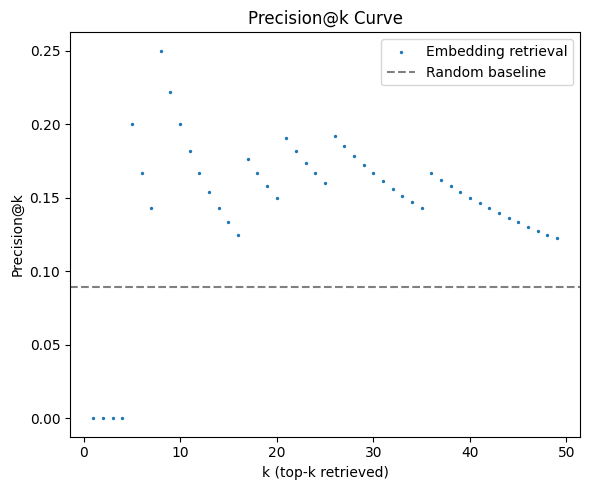

In [344]:
import matplotlib.pyplot as plt

k_vals = np.arange(1, 50)  # limit for readability
k, prec, baseline = precision_at_k_curve(agg_entry['block_emb_dist'], agg_entry['block_coords_dist'], geom_thresh=4.0, k_values=k_vals)

plt.figure(figsize=(6,5))
plt.scatter(k, prec, label="Embedding retrieval", s=2)
plt.axhline(baseline, linestyle="--", color="gray", label="Random baseline")
plt.xlabel("k (top-k retrieved)")
plt.ylabel("Precision@k")
plt.legend()
plt.title("Precision@k Curve")
plt.tight_layout()
plt.show()
